# Output

**What this shows:** how to choose what SCHISM writes and how often, how many scribes
that needs, and how to read the results: 2D and 3D fields and station time series.

**Prerequisites:** [Tutorial 5: Choosing model settings](../tutorial/05_model_settings.ipynb).

**You will learn:**

- how `iof_hydro` flags, `nspool` and `ihfskip` control the output files
- how many scribes an output set needs
- how to read `out2d` and 3D files with xarray and plot them on the mesh
- how to mask dry nodes
- how to write time series at stations

**Data used:** `hgrid.gr3` and `tides/`. The run needs Docker and is skipped
without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "output"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
ASPECT = 1 / np.cos(np.radians(32))

## 1. What to write

`schout.iof_hydro(i)` switches each hydrodynamic output on (1) or off (0). The ones
used most, from the
[SCHISM manual](https://schism-dev.github.io/schism/master/input-output/outputs.html):

| `i` | Output | Kind |
|---|---|---|
| 1 | water level (`elevation`) | 2D |
| 2 | air pressure | 2D |
| 13 | bottom stress | 2D vector |
| 14 | wind | 2D vector |
| 16 | depth-averaged velocity (`depthAverageVelX`, `Y`) | 2D vector |
| 18, 19 | temperature, salinity | 3D |
| 26 | horizontal velocity (`horizontalVelX`, `Y`) | 3D vector |

Modules have their own flags, for example `iof_wwm` for waves.

**How often:** every `nspool` time steps. **Files:** a new file ("stack") every
`ihfskip` time steps, which must be a multiple of `nspool`. With `dt=120` s,
`nspool=15` writes every 30 minutes, and `ihfskip=360` makes a file every 12 hours.

**Scribes:** SCHISM writes output with dedicated processes. It needs one for all 2D
variables, one for the vertical coordinates (always written), and one per 3D
variable, two for vectors. Here: water level and depth-averaged velocity (1), vertical
coordinates (1) and the 3D velocity (2), so **4 scribes**.

In [2]:
output = {
    "iof_hydro__1": 1,  # water level
    "iof_hydro__16": 1,  # depth-averaged velocity
    "iof_hydro__26": 1,  # 3D horizontal velocity: two layers in this 2D model
    "iout_sta": 1,  # station output, below
    "nspool_sta": 15,
}
nml = NML(
    param=Param(
        core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 15, "ihfskip": 360},
        schout=output,
    )
)

## 2. Stations

SCHISM writes time series at points listed in `station.in`, when `iout_sta=1`:
a line of on/off flags for water level, air pressure, wind (x, y), temperature,
salinity and velocity (u, v, w), then the number of stations and one line per
station with its number, longitude, latitude and depth (`z`, for 3D variables).
rompy-schism does not write this file, so it is added to the workspace here.

In [3]:
stations = {
    "Hillarys": (115.73, -31.82),
    "Fremantle": (115.72, -32.06),
    "Rottnest": (115.50, -31.96),
}
lines = ["1 0 0 0 0 0 1 1 0 !elev, pressure, windx, windy, T, S, u, v, w"]
lines.append(f"{len(stations)} !number of stations")
for number, (lon, lat) in enumerate(stations.values(), start=1):
    lines.append(f"{number} {lon} {lat} 0")
station_in = "\n".join(lines) + "\n"
print(station_in)

1 0 0 0 0 0 1 1 0 !elev, pressure, windx, windy, T, S, u, v, w
3 !number of stations
1 115.73 -31.82 0
2 115.72 -32.06 0
3 115.5 -31.96 0



## 3. Run

Two days of tide. The workspace gets `station.in` before SCHISM runs, and SCHISM
runs with 4 scribes.

In [4]:
config = SCHISMConfig(
    grid=SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025),
    data=SCHISMData(
        boundary_conditions=SCHISMDataBoundaryConditions(
            tidal_data=TidalDataset(
                tidal_database=DATA_DIR / "tides",
                tidal_model="TPXO9-perth",
                constituents=["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"],
                nodal_corrections=True,
            ),
            default_boundary=BoundarySetupWithSource(elev_type=3, vel_type=3),
        )
    ),
    nml=nml,
)
period = TimeRange(start="2023-01-01T00:00", end="2023-01-03T00:00", interval="1h")
modelrun = ModelRun(run_id="output", period=period, output_dir=OUT_DIR, config=config)
workspace = Path(modelrun())
(workspace / "station.in").write_text(station_in)


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


if docker_available():
    backend = DockerConfig(
        image=SCHISM_IMAGE, executable="schism 4", mpiexec="mpirun", cpu=8
    )
    modelrun.run(backend, workspace_dir=workspace)
completed = run_completed(workspace)
if completed:
    print(sorted(p.name for p in (workspace / "outputs").glob("*_[0-9].nc")))

['horizontalVelX_1.nc', 'horizontalVelX_2.nc', 'horizontalVelX_3.nc', 'horizontalVelX_4.nc', 'horizontalVelY_1.nc', 'horizontalVelY_2.nc', 'horizontalVelY_3.nc', 'horizontalVelY_4.nc', 'out2d_1.nc', 'out2d_2.nc', 'out2d_3.nc', 'out2d_4.nc', 'zCoordinates_1.nc', 'zCoordinates_2.nc', 'zCoordinates_3.nc', 'zCoordinates_4.nc']


Four stacks of 12 hours, each with an `out2d` file for the 2D variables and one file
per 3D variable (`horizontalVelX`, `horizontalVelY`, `zCoordinates`).

## 4. Reading 2D output

`out2d` files carry the mesh as well as the variables, following the
[UGRID](https://ugrid-conventions.github.io/ugrid-conventions/) conventions. Open all
stacks together with `open_mfdataset`; `data_vars="minimal"` keeps the mesh variables
from being repeated along time.

In [5]:
if completed:
    out2d = xr.open_mfdataset(
        sorted((workspace / "outputs").glob("out2d_*.nc")),
        data_vars="minimal", coords="minimal", compat="override",
    )  # fmt: skip
    print(out2d)

<xarray.Dataset> Size: 24MB
Dimensions:                  (one: 1, nSCHISM_hgrid_node: 6790,
                              nSCHISM_hgrid_face: 12958,
                              nMaxSCHISM_hgrid_face_nodes: 4,
                              nSCHISM_hgrid_edge: 19750, two: 2, time: 96)
Coordinates:
    SCHISM_hgrid_node_x      (nSCHISM_hgrid_node) float64 54kB dask.array<chunksize=(6790,), meta=np.ndarray>
    SCHISM_hgrid_node_y      (nSCHISM_hgrid_node) float64 54kB dask.array<chunksize=(6790,), meta=np.ndarray>
    SCHISM_hgrid_face_x      (nSCHISM_hgrid_face) float64 104kB dask.array<chunksize=(12958,), meta=np.ndarray>
    SCHISM_hgrid_face_y      (nSCHISM_hgrid_face) float64 104kB dask.array<chunksize=(12958,), meta=np.ndarray>
    SCHISM_hgrid_edge_x      (nSCHISM_hgrid_edge) float64 158kB dask.array<chunksize=(19750,), meta=np.ndarray>
    SCHISM_hgrid_edge_y      (nSCHISM_hgrid_edge) float64 158kB dask.array<chunksize=(19750,), meta=np.ndarray>
  * time                     (tim

SCHISM numbers nodes from 1, so subtract 1 from `SCHISM_hgrid_face_nodes` to build a
triangulation. SCHISM still writes a water level at dry nodes, so mask them with
`dryFlagNode` before analysing water levels near the shore. At low water on
2 January, these nodes along the shore are dry:

319 dry nodes; water level masked there: 319


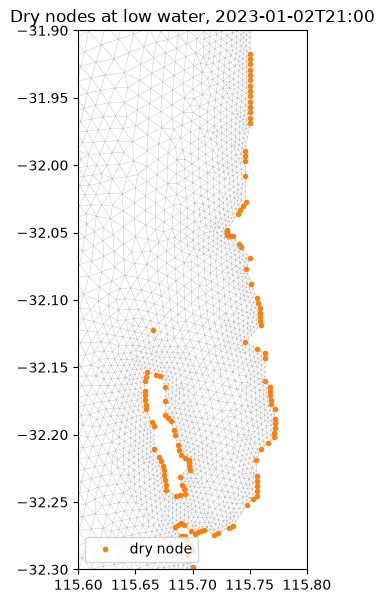

In [6]:
if completed:
    x = out2d.SCHISM_hgrid_node_x.values
    y = out2d.SCHISM_hgrid_node_y.values
    triangulation = mtri.Triangulation(
        x, y, out2d.SCHISM_hgrid_face_nodes.values[:, :3] - 1
    )
    fremantle = np.argmin((x - 115.72) ** 2 + (y + 32.06) ** 2)
    low_water = out2d.elevation[:, fremantle].sel(time="2023-01-02").idxmin().values
    snap = out2d.sel(time=low_water)
    wet_level = snap.elevation.where(snap.dryFlagNode == 0)
    dry = snap.dryFlagNode.values.astype(bool)
    print(f"{dry.sum()} dry nodes; water level masked there: {int(wet_level.isnull().sum())}")

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.triplot(triangulation, color="0.75", linewidth=0.3)
    ax.plot(x[dry], y[dry], "o", color="tab:orange", markersize=3, label="dry node")
    ax.legend(loc="lower left")
    ax.set(
        title=f"Dry nodes at low water, {str(low_water)[:16]}", xlim=(115.6, 115.8),
        ylim=(-32.3, -31.9), aspect=ASPECT,
    )  # fmt: skip

## 5. Reading 3D output

Each 3D variable has its own files, with a level dimension; `zCoordinates` gives the
height of each level. This model is 2D, so there are two levels, the bottom and the
surface, with the same velocity. [Baroclinic 3D model](baroclinic_3d.ipynb) reads a
real 3D model.

In [7]:
if completed:
    velocity = xr.open_mfdataset(
        sorted((workspace / "outputs").glob("horizontalVelX_*.nc")),
        data_vars="minimal", coords="minimal", compat="override",
    )  # fmt: skip
    zcoords = xr.open_dataset(workspace / "outputs" / "zCoordinates_1.nc")
    print(velocity.horizontalVelX)
    print("levels at Fremantle:", zcoords.zCoordinates[0, fremantle].values)

<xarray.DataArray 'horizontalVelX' (time: 96, nSCHISM_hgrid_node: 6790,
                                    nSCHISM_vgrid_layers: 2)> Size: 5MB
dask.array<concatenate, shape=(96, 6790, 2), dtype=float32, chunksize=(1, 6790, 2), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 768B 2023-01-01T00:30:00 ... 2023-01-03
Dimensions without coordinates: nSCHISM_hgrid_node, nSCHISM_vgrid_layers
Attributes:
    i23d:          2
    location:      node
    grid_mapping:  crs
    mesh:          SCHISM_hgrid
levels at Fremantle: [-1.6994404e+01 -1.2477504e-07]


## 6. Station time series

Station output is plain text in `outputs/staout_N`, one file per variable in the
order of the flags (1 water level, 7 and 8 the velocity), with the time in seconds
from the start and one column per station.

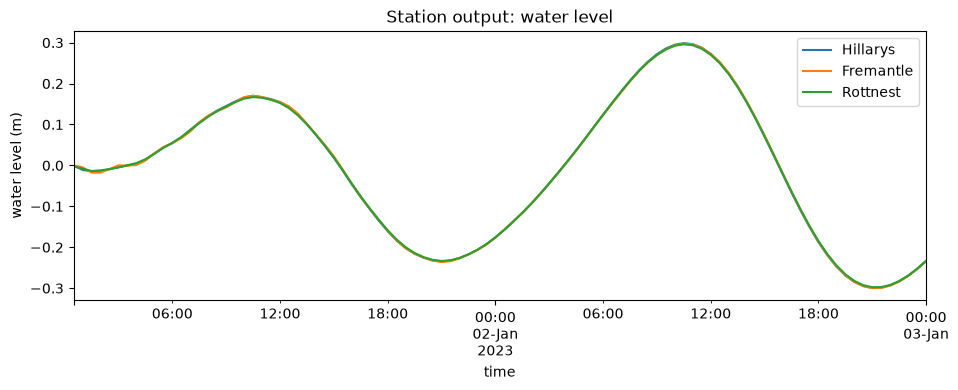

In [8]:
if completed:
    columns = ["time", *stations]
    staout = pd.read_csv(
        workspace / "outputs" / "staout_1", sep=r"\s+", header=None, names=columns
    )
    staout.index = pd.Timestamp(period.start) + pd.to_timedelta(staout.pop("time"), "s")
    ax = staout.plot(figsize=(11, 3.5), ylabel="water level (m)")
    ax.set(title="Station output: water level")

## Summary

- `iof_hydro` flags choose the variables, `nspool` how often, `ihfskip` how many steps
  per file.
- Give SCHISM one scribe for the 2D variables, one for the vertical coordinates and
  one per 3D variable (two for vectors).
- Read `out2d_*.nc` with `open_mfdataset(data_vars="minimal", ...)`; build the mesh
  from `SCHISM_hgrid_face_nodes - 1`, and mask `dryFlagNode`.
- For time series at points, add `station.in` to the workspace and set `iout_sta=1`.